# Real-world Dataset Visualization with NumPy & Matplotlib

In the previous modules, we learned NumPy arithmetic, statistical aggregations, and individual Matplotlib plotting. Now, we will combine everything to perform a **full data analysis and visualization pipeline** on a real-world developer dataset.

We will:
1. Load a real dataset from a CSV file.
2. Clean and filter the data using NumPy masking.
3. Compute metrics like mean and standard deviation.
4. Visualize our findings using multiple plots side-by-side inside a single Figure.

### Simple Explanation with an Everyday Analogy
Imagine you are a **business investigator**:
*   You receive a large ledger book (CSV file) containing employee names, experience, and salaries.
*   You use your highlighter (NumPy Boolean Mask) to mark only the senior employees.
*   You calculate their average salary (NumPy Aggregate).
*   Finally, you draw a dashboard on a whiteboard (Matplotlib Subplots) to show the owner the correlation between experience and salary.

### Code Examples

First, let's write a python script to generate our sample CSV file of developer data.



In [2]:
import numpy as np

# Let's generate a dataset of 100 software developers
# Columns: DevID, YearsExperience, TypeScriptSkill(1-10), Salary(USD)
rng = np.random.default_rng(seed=42)

dev_ids = np.arange(101, 201)
experience = rng.integers(1, 16, size=100) # 1 to 15 years
ts_skill = rng.integers(1, 11, size=100) # Skill level 1 to 10
# Salary is based on experience and TS skill
salary = 40000 + (experience * 5000) + (ts_skill * 3000) + rng.integers(-5000, 5000, size=100)

# Combine into a single matrix
dataset = np.column_stack((dev_ids, experience, ts_skill, salary))

# Save as a CSV file with a header
header = "DevID,YearsExperience,TypeScriptSkill,Salary"
np.savetxt("developer_dataset.csv", dataset, delimiter=",", header=header, comments="")
print("Real-world sample CSV file generated!")

Real-world sample CSV file generated!


Now, let's load this CSV file, perform operations, and plot the results using **Subplots**:


Loaded 100 developer records.
Average Salary: $98076.44
Highest Salary: $142934.00


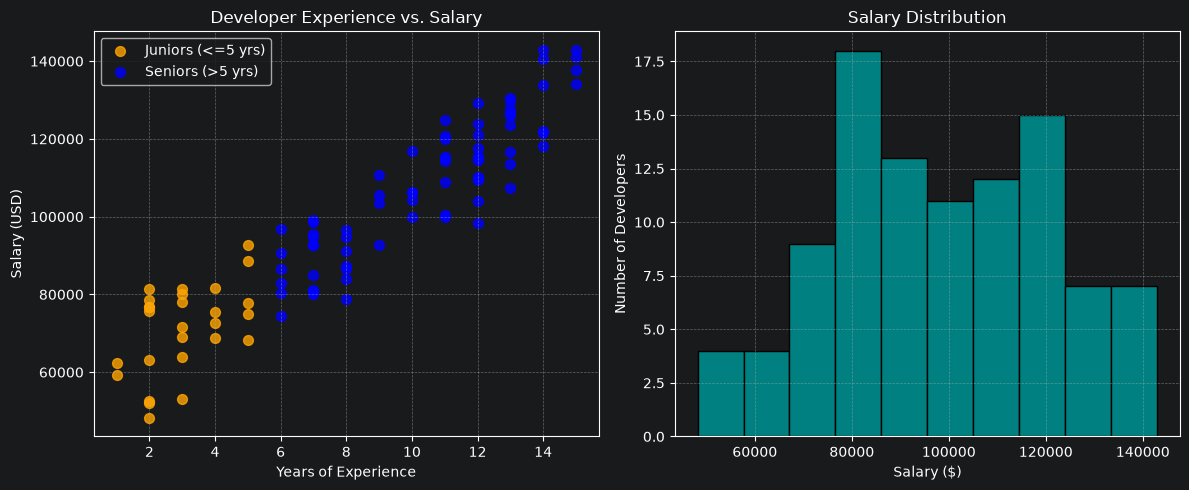

Developer Dashboard generated successfully!


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the data using genfromtxt (skip the header row)
data = np.genfromtxt("developer_dataset.csv", delimiter=",", skip_header=1)

# 2. Extract columns
years_exp = data[:, 1]
ts_skill = data[:, 2]
salaries = data[:, 3]

# 3. Perform stats
avg_salary = np.mean(salaries)
max_salary = np.max(salaries)
print(f"Loaded {len(data)} developer records.")
print(f"Average Salary: ${avg_salary:.2f}")
print(f"Highest Salary: ${max_salary:.2f}")

# 4. Filter: Let's separate developers into Junior (<= 5 years) and Senior (> 5 years)
senior_mask = years_exp > 5
junior_mask = ~senior_mask # The tilde (~) means NOT

senior_salaries = salaries[senior_mask]
junior_salaries = salaries[junior_mask]

# 5. Create a 1 row, 2 columns subplot figure
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Subplot 1: Scatter plot of Experience vs. Salary
# We want to see if more experience leads to higher pay!
axes[0].scatter(years_exp[junior_mask], junior_salaries, color="orange", label="Juniors (<=5 yrs)", alpha=0.8, s=50)
axes[0].scatter(years_exp[senior_mask], senior_salaries, color="blue", label="Seniors (>5 yrs)", alpha=0.8, s=50)
axes[0].set_title("Developer Experience vs. Salary")
axes[0].set_xlabel("Years of Experience")
axes[0].set_ylabel("Salary (USD)")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend()

# Subplot 2: Histogram of Salary Distribution
# Let's see how our developer salaries are distributed!
axes[1].hist(salaries, bins=10, color="teal", edgecolor="black")
axes[1].set_title("Salary Distribution")
axes[1].set_xlabel("Salary ($)")
axes[1].set_ylabel("Number of Developers")
axes[1].grid(True, linestyle="--", alpha=0.5)

# Save the final dashboard
plt.tight_layout()
# plt.savefig("developer_dashboard.png", dpi=150)
plt.show()
plt.close()
print("Developer Dashboard generated successfully!")


### Common Mistakes Beginners Make
1.  **Mismatch in Filtered Array Shapes**:
    *   When plotting a filtered scatter plot (like `axes[0].scatter(years_exp[junior_mask], junior_salaries)`), both the X and Y arrays must be filtered by the **same mask**.
    *   If you write `axes[0].scatter(years_exp, junior_salaries)`, you will get a shape mismatch error because `years_exp` has 100 elements, while `junior_salaries` only has 35 elements!


#### Exercise
Using our generated `developer_dataset.csv`:
1. Filter the dataset to get only developers with a **TypeScriptSkill level of 8 or higher**.
2. Find the average salary of these highly skilled TypeScript developers.
3. Plot a horizontal bar chart comparing the salaries of the first 5 highly-skilled developers (use their `DevID` as categories on the Y-axis and their `Salary` on the X-axis).

Average highly skilled TS salary: $109381.38


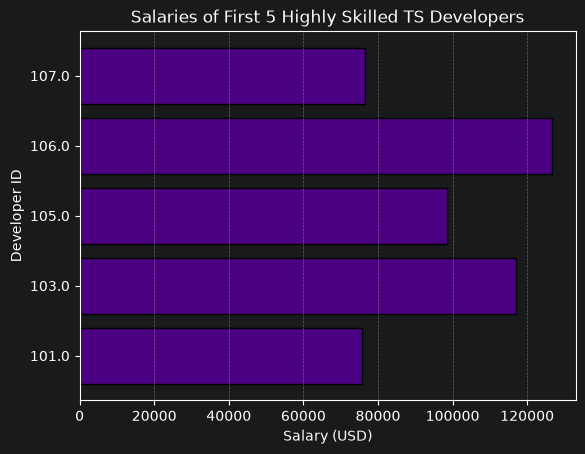

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Load
data = np.genfromtxt("developer_dataset.csv", delimiter=",", skip_header=1)

dev_ids = data[:, 0]
ts_skill = data[:, 2]
salaries = data[:, 3]

# 1. Filter for TS Skill >= 8
skilled_mask = ts_skill >= 8
skilled_ids = dev_ids[skilled_mask]
skilled_salaries = salaries[skilled_mask]

# 2. Average Salary
avg_skilled_salary = np.mean(skilled_salaries)
print(f"Average highly skilled TS salary: ${avg_skilled_salary:.2f}")

# 3. Take first 5 records
top_5_ids = skilled_ids[:5].astype(str) # Convert to string for discrete categories on axis
top_5_salaries = skilled_salaries[:5]

plt.barh(top_5_ids, top_5_salaries, color="indigo", edgecolor="black")
plt.title("Salaries of First 5 Highly Skilled TS Developers")
plt.xlabel("Salary (USD)")
plt.ylabel("Developer ID")
plt.grid(True, axis="x", linestyle="--", alpha=0.5)

# plt.savefig("skilled_developers_bar.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()